In [1]:
import pickle
import copy, os, re
import matplotlib.pyplot as plt
import numpy as np

from uf3.regression import least_squares
from uf3.util import plotting, json_io

/home/sung/miniforge3/envs/uf3/lib/python3.11/site-packages/tables/idxutils.py:351: RuntimeWarning: overflow encountered in cast
  infinitymap['float16'] = [-np.float16(np.inf),
/home/sung/miniforge3/envs/uf3/lib/python3.11/site-packages/tables/idxutils.py:352: RuntimeWarning: overflow encountered in cast
  np.float16(np.inf)]


In [2]:
# Load model in vanilla UF3 format

bspline_config_filename = "bspline_config.pkl"
model_filename = "model.json"

with open(bspline_config_filename, "rb") as f:
    bspline_config = pickle.load(f)

### USE THIS IF LEVEL 2 SYMMETRIZATION WAS USED
#model = least_squares.WeightedLinearModel.from_json(model_filename)

### USE THIS IF LEVEL 1 SYMMETRIZATION WAS USED OR NO SYMMETRIZATION WAS USED
#config = json_io.load_interaction_map(model_filename)
#regularizer = config.get("regularizer", 0)  # we don't want it to create the huge reg matrix by default
#data_coverage = config.get("data_coverage", None)
#model = least_squares.WeightedLinearModel(bspline_config,
#                                          regularizer=regularizer,
#                                          data_coverage=data_coverage)
#model.load(solution=config)

In [ ]:
alchemical_params_filename = "checkpoint/1/alchemical_model_params.npz"
tracker_filename = "checkpoint/train_tracker.npz"

alchemical_params = np.load(alchemical_params_filename)
coeff = alchemical_params["coeff_1b"]
coeff_2b = alchemical_params["coeff_2b"]
pseudo_weights = alchemical_params["pseudo_weights_2b"]

train_tracker = np.load(tracker_filename)
changes_pseudo = train_tracker["change_pw_2b"]
changes_1b = train_tracker["change_coeff_1b"]
changes_2b = train_tracker["change_coeff_2b"]
rmses_e = train_tracker["rmse_e"]
rmses_f = train_tracker["rmse_f"]
data_loss = train_tracker["data_loss"]
total_loss = train_tracker["total_loss"]
times = train_tracker["time"]

In [3]:
# Normalize (for torch only)
#normalization_factor = np.linalg.norm()
#pseudo_weights /= normalization_factor
#coeff_2b *= normalization_factor

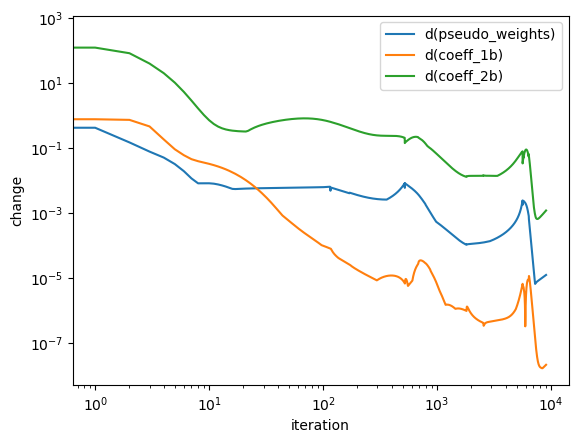

In [5]:
# plot parameter changes in log-log scale
fig, ax = plt.subplots()
ax.plot(changes_pseudo, label="d(pseudo_weights)")
ax.plot(changes_1b, label="d(coeff_1b)")
ax.plot(changes_2b, label="d(coeff_2b)")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlabel("iteration")
ax.set_ylabel("change")
ax.legend()
plt.show()

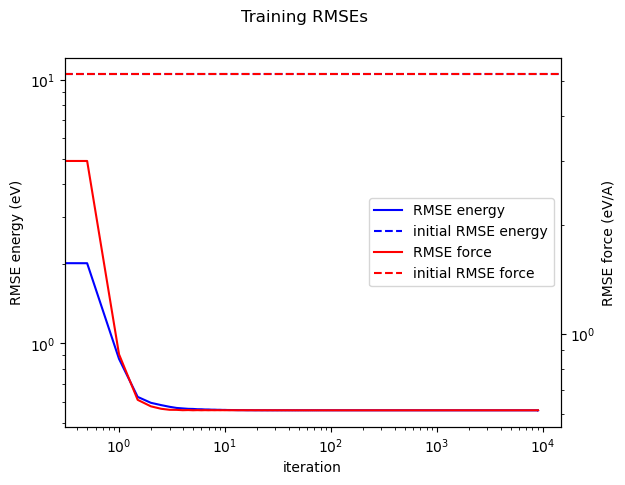

In [10]:
# plot RMSEs on log-log scale
fig, ax_e = plt.subplots()
ax_f = ax_e.twinx()
half_iters = np.arange(0, len(rmses_e)) / 2
rmses_e_curve, = ax_e.plot(half_iters, rmses_e, label="RMSE energy", color="blue")
rmses_f_curve, = ax_f.plot(half_iters, rmses_f, label="RMSE force", color="red")
initial_rmse_e_line = ax_e.axhline(y=rmses_e[0], color="blue", linestyle="--", label="initial RMSE energy")
initial_rmse_f_line = ax_f.axhline(y=rmses_f[0], color="red", linestyle="--", label="initial RMSE force")
ax_e.set_yscale("log")
ax_f.set_yscale("log")
ax_e.set_xscale("log")
ax_e.set_xlabel("iteration")
ax_e.set_ylabel("RMSE energy (eV)")
ax_f.set_ylabel("RMSE force (eV/A)")
# Combine legends
lines = [rmses_e_curve, initial_rmse_e_line, rmses_f_curve, initial_rmse_f_line]
labels = [line.get_label() for line in lines]
ax_e.legend(lines, labels, loc="best")  # Create a combined legend
fig.suptitle("Training RMSEs")
plt.show()

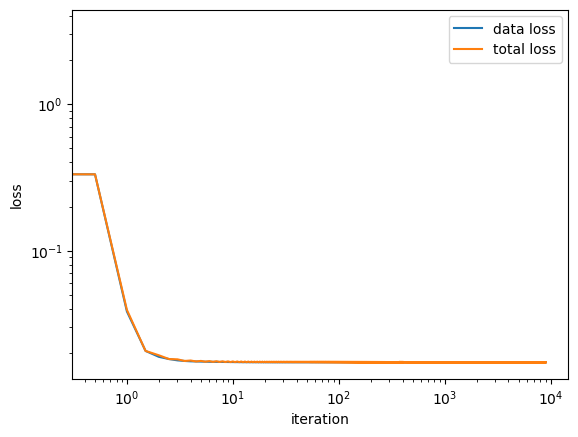

In [14]:
# plot data loss and total loss
fig, ax = plt.subplots()
ax.plot(half_iters, data_loss, label="data loss")
ax.plot(half_iters, total_loss, label="total loss")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlabel("iteration")
ax.set_ylabel("loss")
ax.legend()
#ax.set_ylim(0.017, 0.018)
#ax.set_xlim(5, 10)
plt.show()

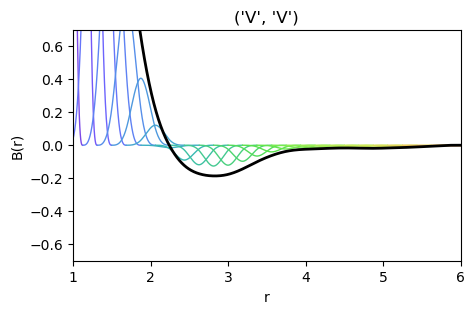

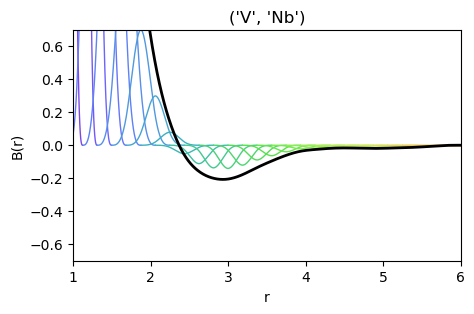

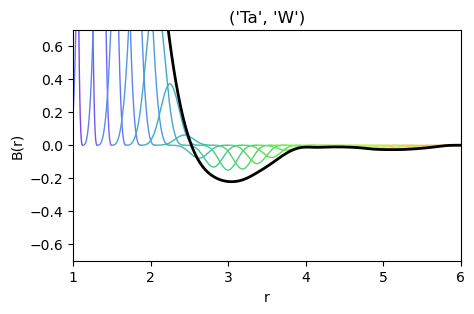

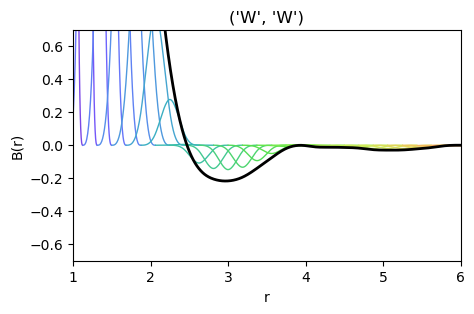

In [15]:
solutions = least_squares.arrange_coefficients(model.coefficients,
                                            bspline_config)

nPlot = 4
for pair in bspline_config.interactions_map[2][:int(nPlot/2)] + bspline_config.interactions_map[2][-int(nPlot/2):]:
#pair = ('Mo', 'Ru')
#if True:
    coefficients = solutions[pair]
    knot_sequence = bspline_config.knots_map[pair]
    fig, ax = plotting.visualize_splines(coefficients, knot_sequence)
    plt.vlines([0.0], -100, 100, color="orange", linewidth=2)
    ax.set_xlim(1, 6)
    ax.set_ylim(-0.7, 0.7)
    ax.set_title(f"{pair}")
    fig.set_size_inches(5, 3)

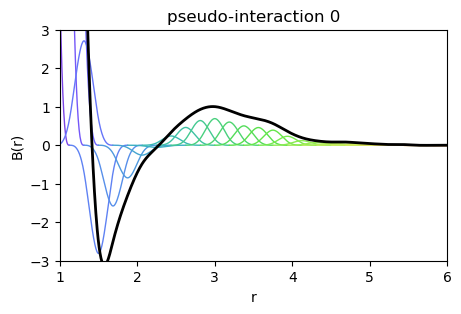

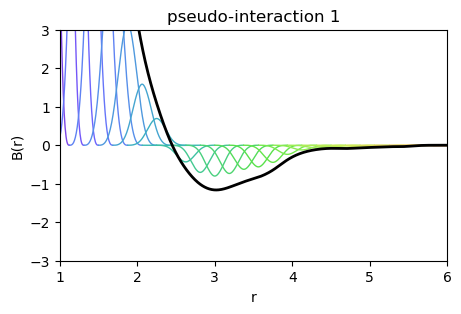

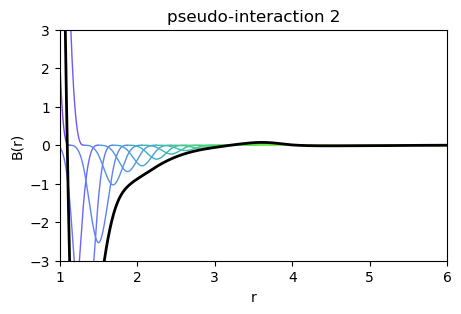

In [17]:
# plot alchemical potentials
n_pseudo = coeff_2b.shape[1]
n_basis = coeff_2b.shape[0]
dummy_model = copy.deepcopy(model)
lead_trim = dummy_model.bspline_config.leading_trim
trail_trim = dummy_model.bspline_config.trailing_trim
offsets = dummy_model.bspline_config.get_interaction_partitions()[1]
dummy_pairs = []
for i in range(n_pseudo):
    dummy_pair = dummy_model.bspline_config.interactions_map[2][i]
    dummy_pairs.append(dummy_pair)
    offset = offsets[dummy_pair]
    normalization = pseudo_weights[:, i][np.argmax(np.abs(pseudo_weights[:, i]))] / np.max(np.abs(pseudo_weights))
    dummy_model.coefficients[offset+lead_trim:offset+lead_trim+n_basis] = coeff_2b[:, i] * normalization

dummy_solutions = least_squares.arrange_coefficients(dummy_model.coefficients,
                                            dummy_model.bspline_config)
for i, pair in enumerate(dummy_pairs):
    coefficients = dummy_solutions[pair]
    knot_sequence = dummy_model.bspline_config.knots_map[pair]
    fig, ax = plotting.visualize_splines(coefficients, knot_sequence)
    plt.vlines([0.0], -100, 100, color="orange", linewidth=2)
    ax.set_xlim(1, 6)
    ax.set_ylim(-3, 3)
    ax.set_title(f"pseudo-interaction {i}")
    fig.set_size_inches(5, 3)

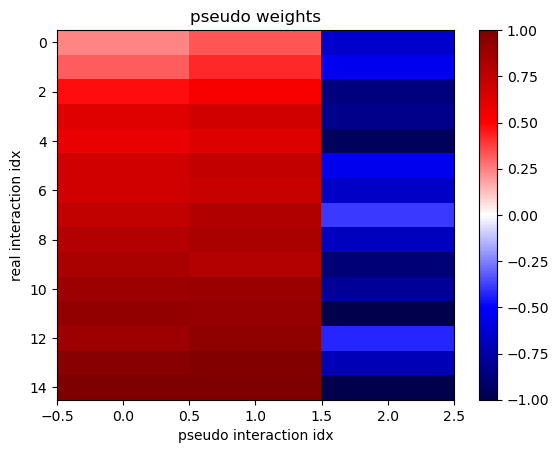

In [18]:
fig, ax = plt.subplots()
cax = ax.imshow(pseudo_weights, cmap='seismic', aspect="auto", interpolation="nearest",
                vmin=-1, vmax=1)
fig.colorbar(cax)
ax.set_xlabel("pseudo interaction idx")
ax.set_ylabel("real interaction idx")
ax.set_title("pseudo weights")
plt.show()